In [ ]:
print('ashana')

ashana


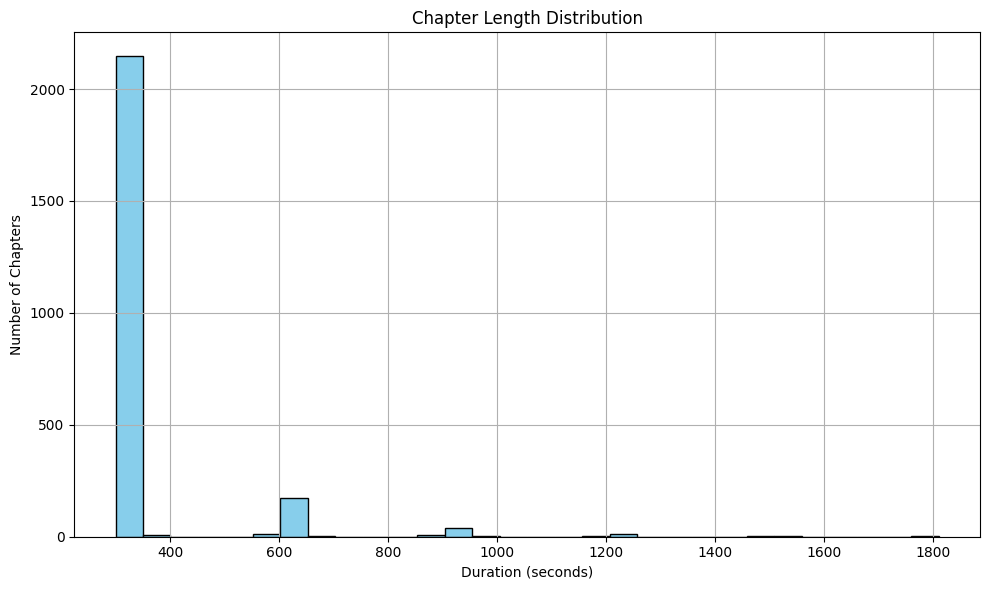

In [ ]:
import zipfile
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from io import BytesIO

# Converts timestamp "HH:MM:SS" to seconds
def timestamp_to_seconds(ts):
    h, m, s = map(int, ts.split(":"))
    return h * 3600 + m * 60 + s

# Process a single JSON content and extract duration of each segment
def extract_lengths(json_data):
    lengths = []
    for i in range(len(json_data) - 1):
        try:
            start = timestamp_to_seconds(json_data[i]["start_time"])
            end = timestamp_to_seconds(json_data[i + 1]["start_time"])
            lengths.append(end - start)
        except Exception as e:
            print(f"Error parsing timestamps: {e}")
    return lengths

# Main function to unzip and process
def process_zip_and_plot(zip_path):
    all_lengths = []

    with zipfile.ZipFile(zip_path, 'r') as archive:
        for file_name in archive.namelist():
            if file_name.endswith(".json"):
                with archive.open(file_name) as f:
                    try:
                        content = json.load(f)
                        if isinstance(content, list):  # assuming direct list
                            lengths = extract_lengths(content)
                        elif isinstance(content, dict) and "chapters" in content:
                            lengths = extract_lengths(content["chapters"])
                        else:
                            continue
                        all_lengths.extend(lengths)
                    except Exception as e:
                        print(f"Failed to process {file_name}: {e}")

    # Plotting the histogram
    if all_lengths:
        plt.figure(figsize=(10, 6))
        plt.hist(all_lengths, bins=30, color='skyblue', edgecolor='black')
        plt.title("Chapter Length Distribution")
        plt.xlabel("Duration (seconds)")
        plt.ylabel("Number of Chapters")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print("No lengths to plot.")

# Example usage
zip_path = "chapter_outputs_mbart.zip"  # <- replace this with your actual zip filename
process_zip_and_plot(zip_path)


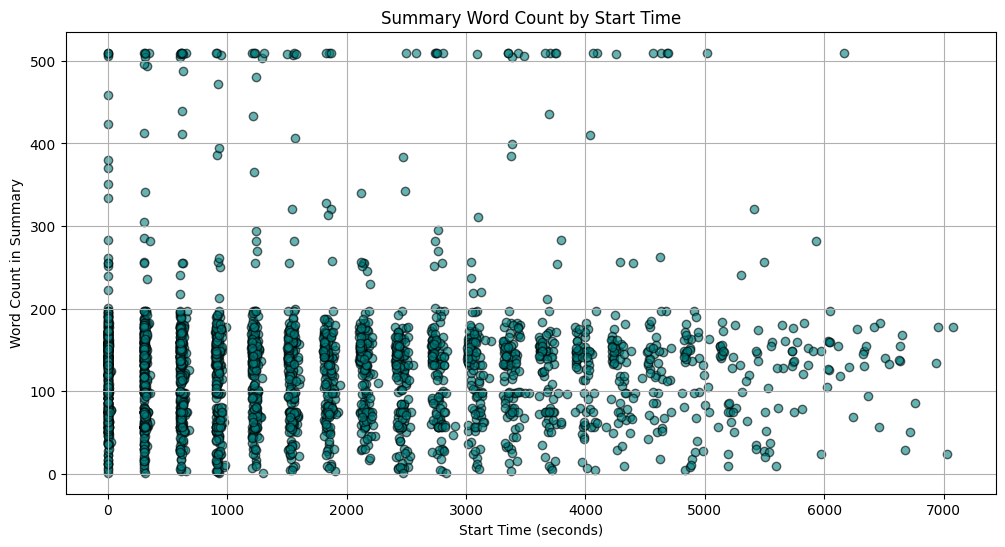

In [ ]:
import zipfile
import json
import matplotlib.pyplot as plt
import os
from datetime import timedelta

def time_to_seconds(time_str):
    """Convert HH:MM:SS string to total seconds."""
    h, m, s = map(int, time_str.split(":"))
    return h * 3600 + m * 60 + s

def extract_and_plot_summary_word_counts(zip_path):
    extract_dir = "extracted_chapters"
    os.makedirs(extract_dir, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    start_times = []
    word_counts = []

    for filename in os.listdir(extract_dir):
        if filename.endswith(".json"):
            file_path = os.path.join(extract_dir, filename)
            with open(file_path, 'r', encoding='utf-8') as f:
                try:
                    chapters = json.load(f)
                    if isinstance(chapters, list):
                        for chapter in chapters:
                            start_time_str = chapter.get("start_time", None)
                            summary = chapter.get("summary", "")
                            if start_time_str and summary:
                                seconds = time_to_seconds(start_time_str)
                                word_count = len(summary.strip().split())
                                start_times.append(seconds)
                                word_counts.append(word_count)
                except Exception as e:
                    print(f"Error reading {filename}: {e}")

    # Plot
    plt.figure(figsize=(12, 6))
    plt.scatter(start_times, word_counts, alpha=0.6, color='teal', edgecolors='k')
    plt.title("Summary Word Count by Start Time")
    plt.xlabel("Start Time (seconds)")
    plt.ylabel("Word Count in Summary")
    plt.grid(True)
    plt.show()

# Provide your ZIP path here
zip_path = "chapter_outputs_mbart.zip"
extract_and_plot_summary_word_counts(zip_path)



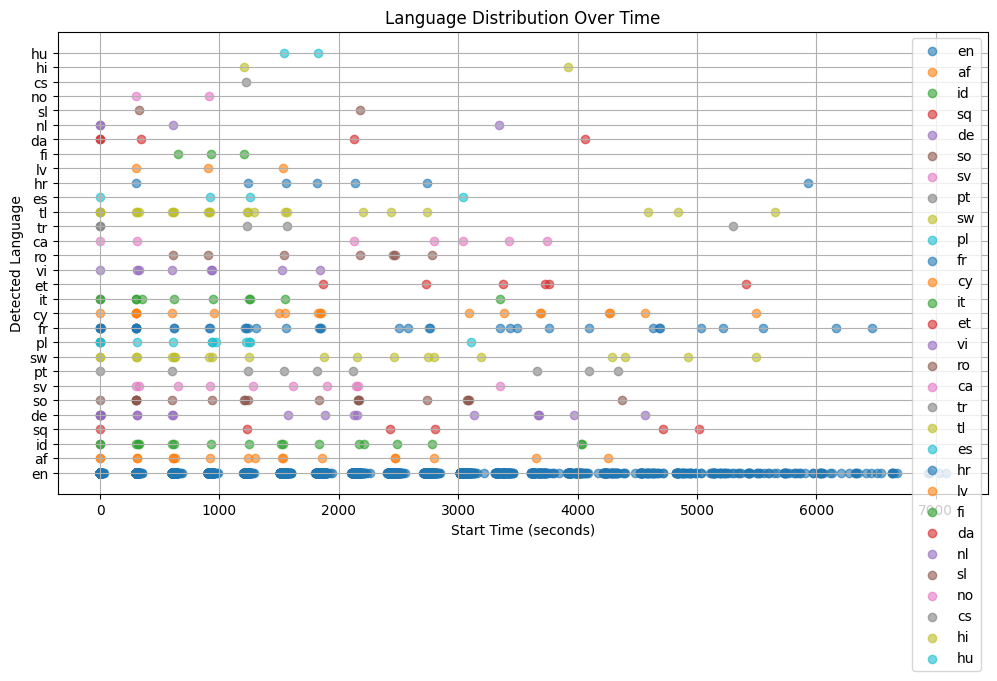

In [ ]:
import zipfile
import json
import os
from langdetect import detect
import matplotlib.pyplot as plt
import pandas as pd

# Function to convert start time like "0:05:00" to seconds
def time_to_seconds(t):
    h, m, s = map(int, t.split(":"))
    return h * 3600 + m * 60 + s

# Function to extract language info from zip
def analyze_language_distribution(zip_path):
    data_list = []

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("extracted_chapters")

        for file_name in zip_ref.namelist():
            if file_name.endswith(".json"):
                file_path = os.path.join("extracted_chapters", file_name)
                with open(file_path, 'r', encoding='utf-8') as f:
                    try:
                        chapters = json.load(f)
                        if isinstance(chapters, list):  # File contains a list of chapters
                            for chapter in chapters:
                                start_time = chapter.get("start_time", None)
                                summary = chapter.get("summary", "")
                                if start_time and summary.strip():
                                    try:
                                        lang = detect(summary)
                                        data_list.append({
                                            "start_time": time_to_seconds(start_time),
                                            "language": lang
                                        })
                                    except:
                                        continue  # If language detection fails
                    except:
                        continue  # If file loading fails

    # Convert to DataFrame
    df = pd.DataFrame(data_list)

    # Plot: Language distribution over time
    plt.figure(figsize=(12, 6))
    for lang in df['language'].unique():
        lang_df = df[df['language'] == lang]
        plt.scatter(lang_df['start_time'], [lang] * len(lang_df), label=lang, alpha=0.6)

    plt.xlabel("Start Time (seconds)")
    plt.ylabel("Detected Language")
    plt.title("Language Distribution Over Time")
    plt.legend()
    plt.grid(True)
    plt.show()

# Use your zip file
zip_path = "chapter_outputs_mbart.zip"
analyze_language_distribution(zip_path)


In [ ]:
!pip install langdetect


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=7feac6cb7ed95d6680a8df75a2105718dc85d1cf21a9521003b247ae96f9c71a
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect


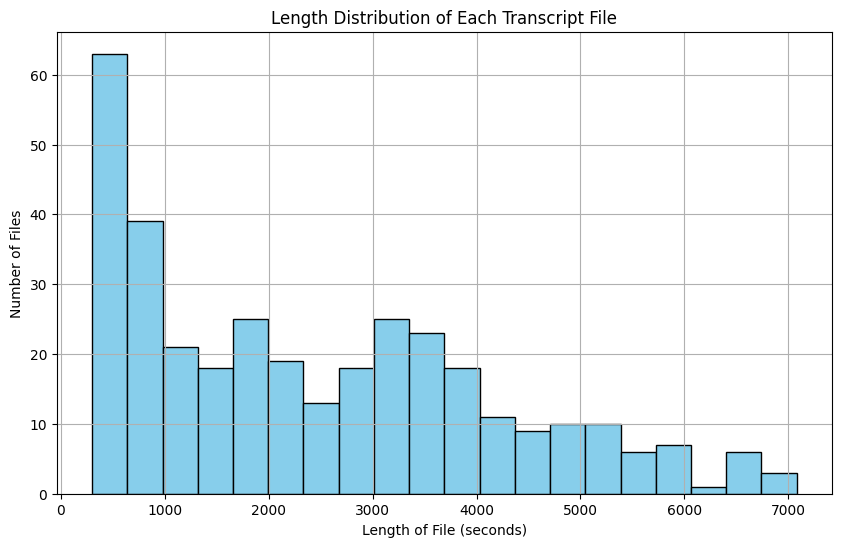

In [ ]:
import zipfile
import json
from datetime import timedelta
import matplotlib.pyplot as plt

def parse_time_to_seconds(time_str):
    """Converts a HH:MM:SS string to seconds."""
    h, m, s = map(int, time_str.split(":"))
    return h * 3600 + m * 60 + s

def plot_file_length_distribution(zip_path):
    file_lengths = []

    with zipfile.ZipFile(zip_path, 'r') as z:
        for file in z.namelist():
            if file.endswith(".json"):
                with z.open(file) as f:
                    try:
                        data = json.load(f)
                        if isinstance(data, list) and len(data) > 1:
                            start_times = [parse_time_to_seconds(entry.get("start_time", "0:00:00")) for entry in data]
                            file_length = max(start_times) - min(start_times)
                            file_lengths.append(file_length)
                    except Exception as e:
                        print(f"Error in {file}: {e}")

    # Plot histogram
    plt.figure(figsize=(10, 6))
    plt.hist(file_lengths, bins=20, color='skyblue', edgecolor='black')
    plt.xlabel("Length of File (seconds)")
    plt.ylabel("Number of Files")
    plt.title("Length Distribution of Each Transcript File")
    plt.grid(True)
    plt.show()

# Use your zip path here
zip_path = "chapter_outputs_mbart.zip"
plot_file_length_distribution(zip_path)


In [ ]:
import pandas as pd

# Create a dictionary of the metrics
data = {
    "Metric": [
        "Average BLEU Score",
        "Average Readability Score",
        "Average Time Gap Between Chapters (sec)",
        "Average Chapter Duration (sec)",
        "Average Human Rating of Chapter"
    ],
    "Value": [
        1.6402,
        25.06,
        284.14,
        284.14,
        "2.75/5"
    ]
}

# Convert to pandas DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
print(df)


                                    Metric   Value
0                       Average BLEU Score  1.6402
1                Average Readability Score   25.06
2  Average Time Gap Between Chapters (sec)  284.14
3           Average Chapter Duration (sec)  284.14
4          Average Human Rating of Chapter  2.75/5


In [ ]:
import pandas as pd
from tabulate import tabulate

# Create a dictionary of the metrics
data = {
    "Metric": [
        "Average BLEU Score",
        "Average Readability Score",
        "Average Time Gap Between Chapters (sec)",
        "Average Chapter Duration (sec)",
        "Average Human Rating of Chapter"
    ],
    "Value": [
        1.6402,
        25.06,
        284.14,
        284.14,
        "2.75/5"
    ]
}

# Convert to pandas DataFrame
df = pd.DataFrame(data)

# Display the DataFrame as a table using tabulate
print(tabulate(df, headers='keys', tablefmt='grid', showindex=False))


+-----------------------------------------+---------+
| Metric                                  | Value   |
+=========================================+=========+
| Average BLEU Score                      | 1.6402  |
+-----------------------------------------+---------+
| Average Readability Score               | 25.06   |
+-----------------------------------------+---------+
| Average Time Gap Between Chapters (sec) | 284.14  |
+-----------------------------------------+---------+
| Average Chapter Duration (sec)          | 284.14  |
+-----------------------------------------+---------+
| Average Human Rating of Chapter         | 2.75/5  |
+-----------------------------------------+---------+
